15
Saved to IMG\daily_stack_Office_no_control.png


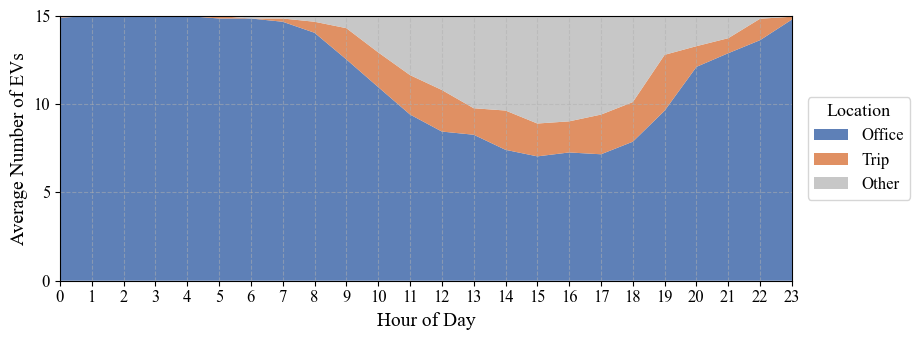

In [12]:
from create_EVmodel3 import EVGroupTrip
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os

plt.rcParams.update({
    'font.family': 'Times New Roman',
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13
})

Num_EV = 15
starttime=datetime(2014,1,1)
endtime=datetime(2015,1,1)
TripType="Office"

evgrouptrip=EVGroupTrip("All",Num_EV,starttime,endtime,False,TripType,10000)

def plot_weekly_parking_stack(evgroup: EVGroupTrip, user_type="Commuter", control=False, filename=None):
    # 各時間帯の時間ラベル（月曜0時〜日曜23時までの168時間）
    week_hour_labels = [(d.weekday(), d.hour) for d in evgroup.TripHourRange]
    label_index = pd.MultiIndex.from_tuples(week_hour_labels, names=["weekday", "hour"])

    # 対象データ（場所ごと）
    home = pd.Series(evgroup.NumHomehour[user_type][control], index=label_index)
    office = pd.Series(evgroup.NumOfficehour[user_type][control], index=label_index)
    trip = pd.Series(evgroup.NumTriphour[user_type][control], index=label_index)

    # Other = 全体台数 - (home + office + trip)
    total_evs = evgroup.NumGroupEV[user_type][control]
    other = total_evs - (home + office + trip)

    # 平均化（曜日・時間ごとの平均）
    mean_home = home.groupby(level=[0, 1]).mean()
    mean_office = office.groupby(level=[0, 1]).mean()
    mean_trip = trip.groupby(level=[0, 1]).mean()
    mean_other = other.groupby(level=[0, 1]).mean()

    # 並べ替え
    def to_weekly_array(series):
        return series.unstack().values.flatten()

    weekly_home = to_weekly_array(mean_home)
    weekly_office = to_weekly_array(mean_office)
    weekly_trip = to_weekly_array(mean_trip)
    weekly_other = to_weekly_array(mean_other)

    # 時間軸・ラベル
    x = np.arange(168)
    weekdays = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    # 0時と12時を表示するためのxticks設定
    xticks = np.arange(0, 168, 12)
    xticklabels = []
    for i in range(7):
        xticklabels.append(f"{weekdays[i]} 0h")
        xticklabels.append(f"{weekdays[i]} 12h")

    # 描画
    plt.figure(figsize=(12, 6))
    #sns.set_style("whitegrid")

    plt.stackplot(x,
                    #weekly_home,
                    weekly_office,
                    weekly_trip,
                    weekly_other,
                    labels=["Office", "Trip", "Other"],
                    colors=["blue", "green", "gray"],
                    alpha=0.85)

    plt.xlabel("Hour of Week")
    plt.ylabel("Average Number of EVs")
    plt.xticks(ticks=xticks, labels=xticklabels, rotation=45)
    plt.xlim([0, 167])

    # 凡例を枠外に
    plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), title="Location")
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)

    # 保存処理
    os.makedirs("IMG", exist_ok=True)
    if filename is None:
        filename = f"weekly_stack_{user_type}_{'control' if control else 'no_control'}.png"
    save_path = os.path.join("IMG", filename)
    plt.savefig(save_path, bbox_inches="tight")
    print(f"Saved to {save_path}")

    # 表示
    plt.show()

def plot_daily_parking_stack(evgroup: EVGroupTrip, user_type="Commuter", control=False, filename=None):
    # 各時間帯の時間ラベル（月曜0時〜日曜23時までの168時間）
    week_hour_labels = [(d.weekday(), d.hour) for d in evgroup.TripHourRange]
    label_index = pd.MultiIndex.from_tuples(week_hour_labels, names=["weekday", "hour"])

    # 対象データ（場所ごと）
    home = pd.Series(evgroup.NumHomehour[user_type][control], index=label_index)
    office = pd.Series(evgroup.NumOfficehour[user_type][control], index=label_index)
    trip = pd.Series(evgroup.NumTriphour[user_type][control], index=label_index)

    # Other = 全体台数 - (home + office + trip)
    total_evs = evgroup.NumGroupEV[user_type][control]
    other = total_evs - (home + office + trip)

    # 平日のみ抽出（weekday 0〜4）
    home_weekday = home.loc[home.index.get_level_values('weekday') < 5]
    office_weekday = office.loc[office.index.get_level_values('weekday') < 5]
    trip_weekday = trip.loc[trip.index.get_level_values('weekday') < 5]
    other_weekday = other.loc[other.index.get_level_values('weekday') < 5]

    # 1日の各時間（0〜23）で平均（平日のみ）
    mean_home = home_weekday.groupby(level=1).mean()
    mean_office = office_weekday.groupby(level=1).mean()
    mean_trip = trip_weekday.groupby(level=1).mean()
    mean_other = other_weekday.groupby(level=1).mean()

    # 時間軸
    x = np.arange(24)

    # 描画
    plt.figure(figsize=(9.3, 3.5))
    #sns.set_style("whitegrid")

    plt.stackplot(x,
                  mean_office,
                  mean_trip,
                  mean_other,
                  labels=["Office", "Trip", "Other"],
                  colors=["#4C72B0", "#DD8452", "#C1C1C1"],
                  alpha=0.9)

    # 軸ラベル
    plt.xlabel("Hour of Day", fontsize=14)
    plt.ylabel("Average Number of EVs", fontsize=14)

    # 目盛ラベル
    plt.xticks(ticks=np.arange(0, 24, 1), fontsize=12)
    plt.yticks(ticks=np.arange(0, Num_EV+1, 5),fontsize=12)

    # 凡例
    plt.legend(loc="center left", bbox_to_anchor=(1.01, 0.5),
            title="Location", fontsize=12, title_fontsize=13)

    plt.xlim([0, 23])
    plt.ylim([0,Num_EV])

    # 凡例を枠外に
    plt.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.5)

    # 保存処理
    os.makedirs("IMG", exist_ok=True)
    if filename is None:
        filename = f"daily_stack_{user_type}_{'control' if control else 'no_control'}.png"
    save_path = os.path.join("IMG", filename)
    plt.savefig(save_path, bbox_inches="tight")
    print(f"Saved to {save_path}")

    # 表示
    plt.show()

print(Num_EV)
#plot_weekly_parking_stack(evgroup=evgrouptrip, user_type="Office", control=False)
plot_daily_parking_stack(evgroup=evgrouptrip, user_type="Office", control=False)

Saved to IMG\weekly_stack_Office_no_control.png


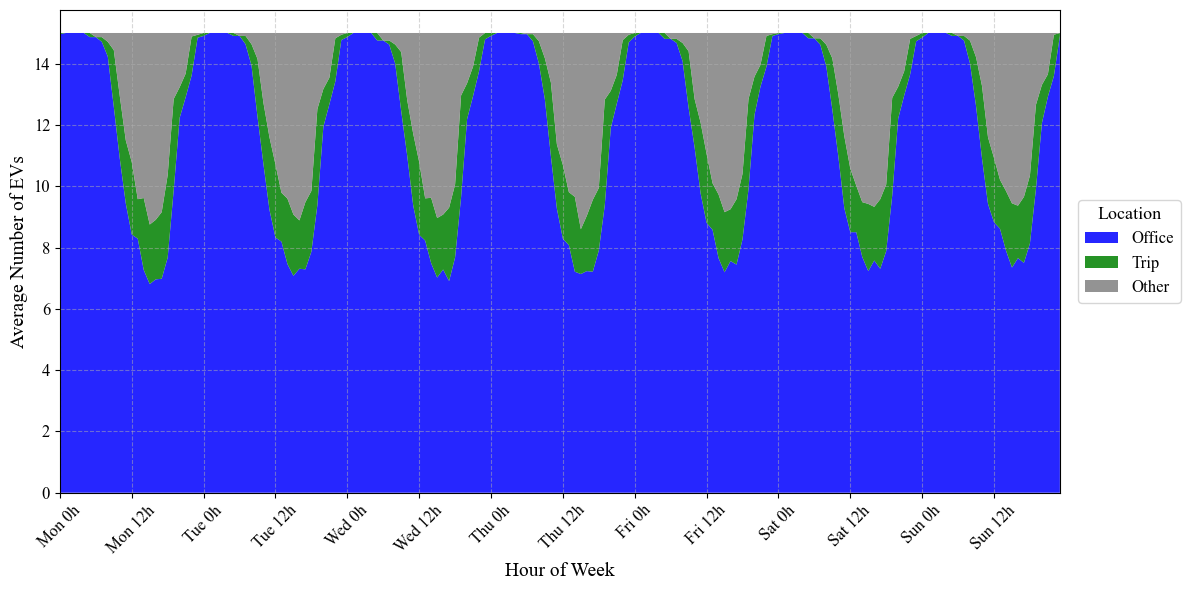

In [13]:
plot_weekly_parking_stack(evgroup=evgrouptrip, user_type="Office", control=False, filename=None)

In [14]:
sum(evgrouptrip.EVGroupTriphour["Office"][True])/15

92564666.66666667